# Turn 2D pose estimation into 3D

In [1]:
from mpl_toolkits.mplot3d import Axes3D
from pose_3d_projector import Pose3DProjector
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.patches as patches


# Set up notebook to display plots inline
%matplotlib inline

print("✓ Imports successful!")

✓ Imports successful!


## Setup file paths

The toml file was made using the freemocap software suite

In [2]:
from pathlib import Path

# ✅ Change only this:
SESSION_DIR = Path("/Users/robertseymour/scripts/space_palm_game/recordings/sub-RS_task-space_validation_date-2026-02-18-15-40-08/block_01_left")

# --- Derived paths (don’t edit these) ---
# one level up ⬆️
CALIBRATION_FILE = SESSION_DIR.parent / "camera_calibration.toml"
KEYPOINTS_2D_DIR   = SESSION_DIR / "mediapipe_output" / "data_2d"
OUTPUT_3D_DIR      = SESSION_DIR / "data_3d"
VISUALIZATION_DIR  = SESSION_DIR / "visualizations"

# (Optional) create output dirs if missing
OUTPUT_3D_DIR.mkdir(parents=True, exist_ok=True)
VISUALIZATION_DIR.mkdir(parents=True, exist_ok=True)

print(f"Session:            {SESSION_DIR}")
print(f"Calibration file:   {CALIBRATION_FILE}")
print(f"2D keypoints dir:   {KEYPOINTS_2D_DIR}")
print(f"3D output dir:      {OUTPUT_3D_DIR}")
print(f"Visualization dir:  {VISUALIZATION_DIR}")

# Verify files exist
calib_path = Path(CALIBRATION_FILE)
keypoints_path = Path(KEYPOINTS_2D_DIR)

if calib_path.exists():
    print("✓ Calibration file found")
else:
    print("✗ ERROR: Calibration file not found!")

if keypoints_path.exists():
    npy_files = list(keypoints_path.glob("*_keypoints.npy"))
    print(f"✓ Found {len(npy_files)} camera keypoint files")
    for f in npy_files:
        print(f"  - {f.name}")
else:
    print("✗ ERROR: 2D keypoints directory not found!")

# Create output directories
Path(OUTPUT_3D_DIR).mkdir(parents=True, exist_ok=True)
Path(VISUALIZATION_DIR).mkdir(parents=True, exist_ok=True)
print("✓ Output directories ready")

Session:            /Users/robertseymour/scripts/space_palm_game/recordings/sub-RS_task-space_validation_date-2026-02-18-15-40-08/block_01_left
Calibration file:   /Users/robertseymour/scripts/space_palm_game/recordings/sub-RS_task-space_validation_date-2026-02-18-15-40-08/camera_calibration.toml
2D keypoints dir:   /Users/robertseymour/scripts/space_palm_game/recordings/sub-RS_task-space_validation_date-2026-02-18-15-40-08/block_01_left/mediapipe_output/data_2d
3D output dir:      /Users/robertseymour/scripts/space_palm_game/recordings/sub-RS_task-space_validation_date-2026-02-18-15-40-08/block_01_left/data_3d
Visualization dir:  /Users/robertseymour/scripts/space_palm_game/recordings/sub-RS_task-space_validation_date-2026-02-18-15-40-08/block_01_left/visualizations
✓ Calibration file found
✓ Found 3 camera keypoint files
  - camera_2_synchronized_keypoints.npy
  - camera_0_synchronized_keypoints.npy
  - camera_1_synchronized_keypoints.npy
✓ Output directories ready


### Optional - clean up the points

In [3]:
from pose_processor import MediaPipePoseProcessor

# Default settings (recommended starting point)
cleaned = MediaPipePoseProcessor.clean_keypoints_directory(
    input_dir=KEYPOINTS_2D_DIR,
    output_dir = Path(KEYPOINTS_2D_DIR) / "data_2d_cleaned",
    frame_width=1024,
    remove_lower_body=False,
    frame_height=576,
    edge_margin_px=50,  # Tune if needed
    confidence_reduction_factor=0.3  # Tune if needed
)

2026-02-23 11:28:26,816 - INFO - Found 3 keypoint files to clean
2026-02-23 11:28:26,816 - INFO - Frame dimensions: 1024x576
2026-02-23 11:28:26,817 - INFO - Remove lower body: False
2026-02-23 11:28:26,817 - INFO - Detect face edge: True
2026-02-23 11:28:26,818 - INFO - Face edge strategy: reduce_confidence
2026-02-23 11:28:26,819 - INFO - Edge margin: 50px (distance from frame edge)
2026-02-23 11:28:26,819 - INFO - Confidence reduction: 0.3 (suspicious faces → 30% confidence)
2026-02-23 11:28:26,820 - INFO - ======================================================================
2026-02-23 11:28:26,820 - INFO - 
Processing camera_2_synchronized_keypoints.npy...
2026-02-23 11:28:26,823 - INFO -   Loaded: (1893, 33, 3)
2026-02-23 11:28:26,872 - INFO -   ✓ Reduced confidence for 0 suspicious face landmarks (0.0%) to 30%
2026-02-23 11:28:26,874 - INFO -   ✓ Saved: /Users/robertseymour/scripts/space_palm_game/recordings/sub-RS_task-space_validation_date-2026-02-18-15-40-08/block_01_left/me

## Initialsie the 3D projector

In [4]:
projector = Pose3DProjector(
    calibration_path=CALIBRATION_FILE,
    keypoints_dir=Path(KEYPOINTS_2D_DIR) / "data_2d_cleaned",

    # ── Core triangulation ──
    min_cameras_for_triangulation=2,  # Need at least this many cameras with
                                      # good confidence to triangulate a point.
                                      # If fewer pass the threshold → NaN.

    # ── Confidence thresholds (filter BEFORE triangulation) ──
    confidence_threshold=0.5,          # MediaPipe visibility score cutoff for
                                       # body landmarks (shoulders, hips, knees, etc.)

    face_confidence_threshold=0.6,     # Stricter for face landmarks (indices 0-10).
                                       # Defaults to confidence_threshold + 0.2.
                                       # These are the ones that hallucinate most
                                       # during occlusion / frame edge.

    hand_confidence_threshold=0.6,     # Stricter for hand landmarks (pinky, index,
                                       # thumb — indices 17-22).
                                       # Defaults to confidence_threshold + 0.1.

    # ── Outlier rejection (filter DURING triangulation) ──
    reprojection_error_threshold=20.0, # After initial DLT solve, if any single
                                       # camera's reprojection error exceeds this
                                       # (in pixels), drop that camera and
                                       # re-triangulate with the rest.

    use_iterative_rejection=True,      # Enable/disable the above. Up to 2 passes.
                                       # Only drops a camera if enough remain
                                       # (>= min_cameras_for_triangulation).
)

print("\n✓ 3D Projector initialized!")
print(f"  - Cameras loaded: {len(projector.cameras)}")
print(f"  - Camera names: {list(projector.cameras.keys())}")


2026-02-23 11:28:29,743 - INFO - Loaded calibration for 3 cameras
2026-02-23 11:28:29,745 - INFO - Loaded camera_2_synchronized: shape (1893, 33, 3)
2026-02-23 11:28:29,748 - INFO - Loaded camera_0_synchronized: shape (1893, 33, 3)
2026-02-23 11:28:29,750 - INFO - Loaded camera_1_synchronized: shape (1893, 33, 3)
2026-02-23 11:28:29,750 - INFO - Loaded 2D keypoints from 3 cameras



✓ 3D Projector initialized!
  - Cameras loaded: 3
  - Camera names: ['camera_0_synchronized', 'camera_1_synchronized', 'camera_2_synchronized']


## Triangulate

In [5]:
# This performs Direct Linear Transform (DLT) triangulation on every frame

print("\n" + "="*70)
print("Starting 3D triangulation...")
print("="*70)

# This will triangulate all keypoints for all frames
# You'll see a progress bar
points_3d, metrics = projector.triangulate_all_frames()

print("\n✓ Triangulation complete!")
print(f"  - 3D points shape: {points_3d.shape}")
print(f"  - Format: (n_frames, n_keypoints, 3) where last dim is [x, y, z] in mm")


2026-02-23 11:28:32,009 - INFO - Triangulating frames 0 to 1893



Starting 3D triangulation...


Triangulating: 100%|██████████| 1893/1893 [00:05<00:00, 362.91it/s]
2026-02-23 11:28:37,251 - INFO - Triangulation complete!



✓ Triangulation complete!
  - 3D points shape: (1893, 33, 3)
  - Format: (n_frames, n_keypoints, 3) where last dim is [x, y, z] in mm


In [6]:
# Post-process: NaN out any keypoint whose mean reprojection error exceeds 15px
points_3d = Pose3DProjector.nan_filter_by_reprojection_error(
    points_3d,
    metrics,
    per_keypoint=False,
    error_threshold=15.0,
)

/Users/robertseymour/scripts/CamKit3D/pose_3d_projector.py:687: RuntimeWarning: Mean of empty slice
  mean_reproj = np.nanmean(metrics.reprojection_errors, axis=2)
2026-02-23 11:28:49,309 - INFO - nan_filter_by_reprojection_error: removed 0/62469 points (0.0%) with error_threshold=15.0px


In [7]:
print("\n" + "="*70)
print("3D PROJECTION QUALITY METRICS")
print("="*70)

print(f"\nFrames processed:              {metrics.n_frames}")
print(f"Keypoints per frame:           {metrics.n_keypoints}")
print(f"Cameras used:                  {metrics.n_cameras}")

print(f"\nReprojection Errors (pixels):")
print(f"  Mean:                        {metrics.mean_reprojection_error:.4f}")
print(f"  Median:                      {metrics.median_reprojection_error:.4f}")
print(f"  Std Dev:                     {metrics.std_reprojection_error:.4f}")
print(f"  Max:                         {metrics.max_reprojection_error:.4f}")

print(f"\nReconstruction Quality:")
print(f"  Frames with good recon:      {metrics.frames_with_good_reconstruction}")
print(f"  Good reconstruction rate:    {metrics.frames_with_good_reconstruction/metrics.n_frames*100:.2f}%")
print(f"  Threshold used:              {metrics.good_reconstruction_threshold:.2f} pixels")

# Quality assessment
if metrics.mean_reprojection_error < 5:
    print("\n✓ EXCELLENT quality - Mean error < 5 pixels")
elif metrics.mean_reprojection_error < 10:
    print("\n✓ GOOD quality - Mean error < 10 pixels")
else:
    print("\n⚠ WARNING - High reprojection error. Check calibration and synchronization.")


3D PROJECTION QUALITY METRICS

Frames processed:              1893
Keypoints per frame:           33
Cameras used:                  3

Reprojection Errors (pixels):
  Mean:                        7.5156
  Median:                      6.3371
  Std Dev:                     6.4020
  Max:                         65.4539

Reconstruction Quality:
  Frames with good recon:      1797
  Good reconstruction rate:    94.93%
  Threshold used:              10.00 pixels

✓ GOOD quality - Mean error < 10 pixels


In [8]:
print("\n" + "="*70)
print("Saving 3D data...")
print("="*70)

# Save the 3D points
projector.save_3d_data(
    points_3d,
    output_path=str(Path(OUTPUT_3D_DIR) / "pose_3d"),
    metadata={
        'min_cameras': 2,
        'confidence_threshold': 0.3
    }
)

# Save the metrics
projector.save_metrics(
    metrics,
    output_path=str(Path(OUTPUT_3D_DIR) / "projection_metrics.txt")
)

print("✓ 3D data saved!")

2026-02-23 11:28:57,865 - INFO - Saved 3D points to /Users/robertseymour/scripts/space_palm_game/recordings/sub-RS_task-space_validation_date-2026-02-18-15-40-08/block_01_left/data_3d/pose_3d.npy
2026-02-23 11:28:57,868 - INFO - Saved metadata to /Users/robertseymour/scripts/space_palm_game/recordings/sub-RS_task-space_validation_date-2026-02-18-15-40-08/block_01_left/data_3d/pose_3d.json
2026-02-23 11:28:57,870 - INFO - Saved metrics to /Users/robertseymour/scripts/space_palm_game/recordings/sub-RS_task-space_validation_date-2026-02-18-15-40-08/block_01_left/data_3d/projection_metrics.txt



Saving 3D data...
✓ 3D data saved!


## Visualize reprojection errors

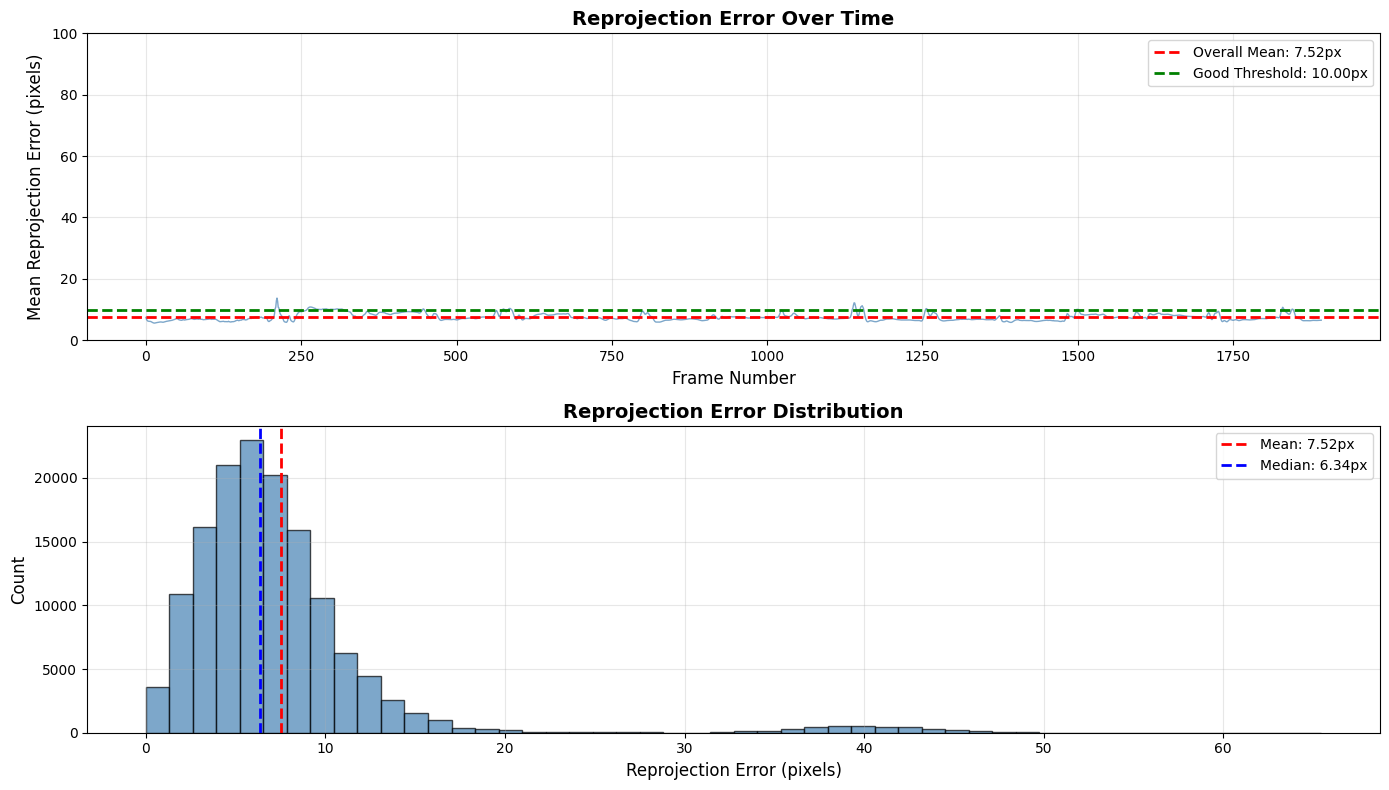

✓ Reprojection error plot saved to: /Users/robertseymour/scripts/space_palm_game/recordings/sub-RS_task-space_validation_date-2026-02-18-15-40-08/block_01_left/visualizations/reprojection_errors.png


In [9]:
# Compute mean error per frame
mean_errors_per_frame = np.nanmean(metrics.reprojection_errors, axis=(1, 2))

# Create figure
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Plot 1: Error over time
axes[0].plot(mean_errors_per_frame, linewidth=1, alpha=0.7, color='steelblue')
axes[0].axhline(
    metrics.mean_reprojection_error, 
    color='red', 
    linestyle='--', 
    label=f'Overall Mean: {metrics.mean_reprojection_error:.2f}px',
    linewidth=2
)
axes[0].axhline(
    metrics.good_reconstruction_threshold, 
    color='green', 
    linestyle='--', 
    label=f'Good Threshold: {metrics.good_reconstruction_threshold:.2f}px',
    linewidth=2
)
axes[0].set_ylim([0,100])
axes[0].set_xlabel('Frame Number', fontsize=12)
axes[0].set_ylabel('Mean Reprojection Error (pixels)', fontsize=12)
axes[0].set_title('Reprojection Error Over Time', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Plot 2: Error distribution histogram
valid_errors = metrics.reprojection_errors[~np.isnan(metrics.reprojection_errors)].flatten()
axes[1].hist(valid_errors, bins=50, alpha=0.7, edgecolor='black', color='steelblue')
axes[1].axvline(
    metrics.mean_reprojection_error, 
    color='red', 
    linestyle='--', 
    label=f'Mean: {metrics.mean_reprojection_error:.2f}px',
    linewidth=2
)
axes[1].axvline(
    metrics.median_reprojection_error, 
    color='blue', 
    linestyle='--', 
    label=f'Median: {metrics.median_reprojection_error:.2f}px',
    linewidth=2
)
axes[1].set_xlabel('Reprojection Error (pixels)', fontsize=12)
axes[1].set_ylabel('Count', fontsize=12)
axes[1].set_title('Reprojection Error Distribution', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
error_plot_path = Path(VISUALIZATION_DIR) / "reprojection_errors.png"
plt.savefig(error_plot_path, dpi=150, bbox_inches='tight')
plt.show()

print(f"✓ Reprojection error plot saved to: {error_plot_path}")

## Quick visualisation

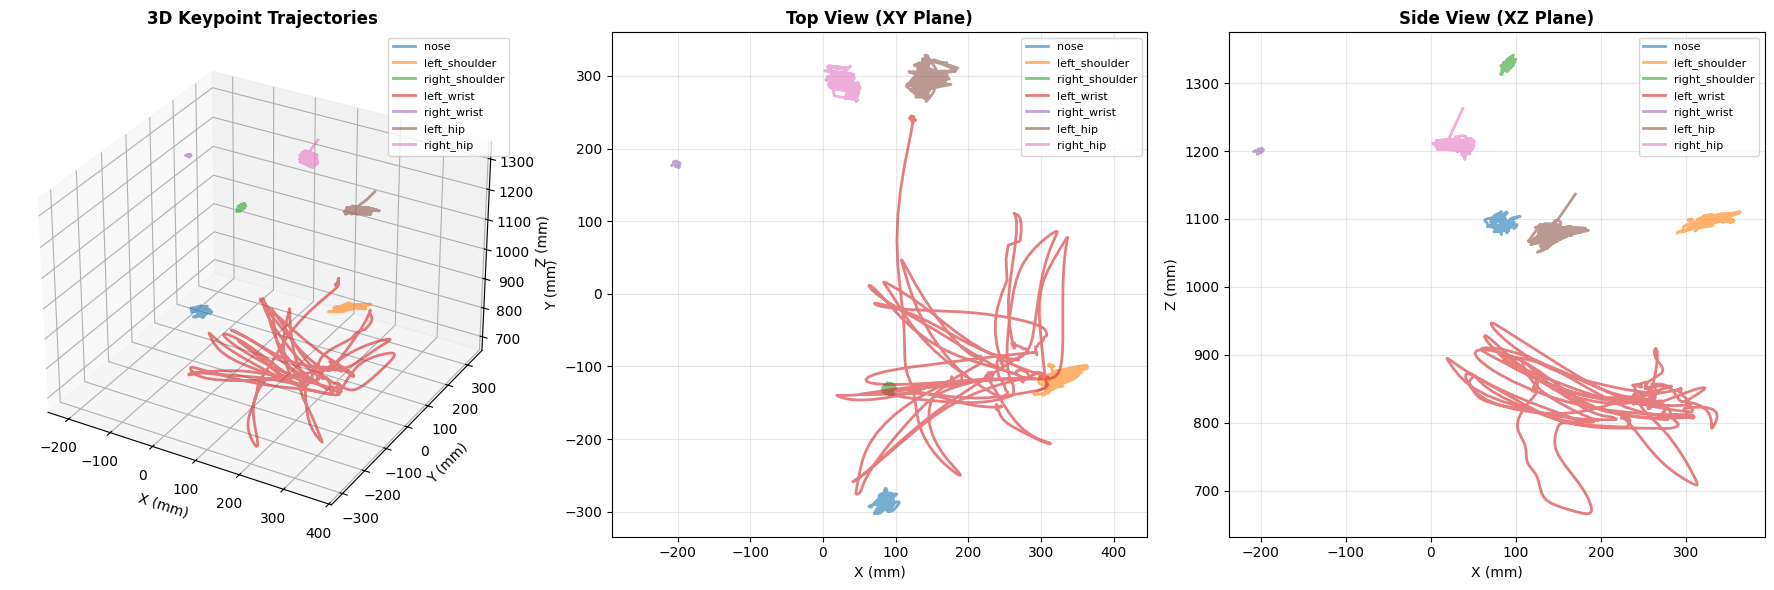

✓ 3D trajectory plot saved to: /Users/robertseymour/scripts/space_palm_game/recordings/sub-RS_task-space_validation_date-2026-02-18-15-40-08/block_01_left/visualizations/3d_trajectories.png


In [10]:
# Plot the 3D movement of key body points

# Select key keypoints to visualize (you can change these)
key_keypoints = {
    0: 'nose',
    11: 'left_shoulder',
    12: 'right_shoulder',
    15: 'left_wrist',
    16: 'right_wrist',
    23: 'left_hip',
    24: 'right_hip'
}

fig = plt.figure(figsize=(18, 6))

# Plot 1: 3D trajectory
ax1 = fig.add_subplot(131, projection='3d')

for idx, name in key_keypoints.items():
    trajectory = points_3d[:, idx, :]
    valid = ~np.isnan(trajectory).any(axis=1)
    
    if np.sum(valid) > 0:
        ax1.plot(
            trajectory[valid, 0],
            trajectory[valid, 1],
            trajectory[valid, 2],
            alpha=0.6,
            label=name,
            linewidth=2
        )

ax1.set_xlabel('X (mm)', fontsize=10)
ax1.set_ylabel('Y (mm)', fontsize=10)
ax1.set_zlabel('Z (mm)', fontsize=10)
ax1.set_title('3D Keypoint Trajectories', fontsize=12, fontweight='bold')
ax1.legend(fontsize=8, loc='upper right')

# Plot 2: Top view (XY plane)
ax2 = fig.add_subplot(132)

for idx, name in key_keypoints.items():
    trajectory = points_3d[:, idx, :]
    valid = ~np.isnan(trajectory).any(axis=1)
    
    if np.sum(valid) > 0:
        ax2.plot(
            trajectory[valid, 0],
            trajectory[valid, 1],
            alpha=0.6,
            label=name,
            linewidth=2
        )

ax2.set_xlabel('X (mm)', fontsize=10)
ax2.set_ylabel('Y (mm)', fontsize=10)
ax2.set_title('Top View (XY Plane)', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=8)
ax2.axis('equal')

# Plot 3: Side view (XZ plane)
ax3 = fig.add_subplot(133)

for idx, name in key_keypoints.items():
    trajectory = points_3d[:, idx, :]
    valid = ~np.isnan(trajectory).any(axis=1)
    
    if np.sum(valid) > 0:
        ax3.plot(
            trajectory[valid, 0],
            trajectory[valid, 2],
            alpha=0.6,
            label=name,
            linewidth=2
        )

ax3.set_xlabel('X (mm)', fontsize=10)
ax3.set_ylabel('Z (mm)', fontsize=10)
ax3.set_title('Side View (XZ Plane)', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3)
ax3.legend(fontsize=8)

plt.tight_layout()
trajectory_plot_path = Path(VISUALIZATION_DIR) / "3d_trajectories.png"
plt.savefig(trajectory_plot_path, dpi=150, bbox_inches='tight')
plt.show()

print(f"✓ 3D trajectory plot saved to: {trajectory_plot_path}")



## Some simple kinematic analysis

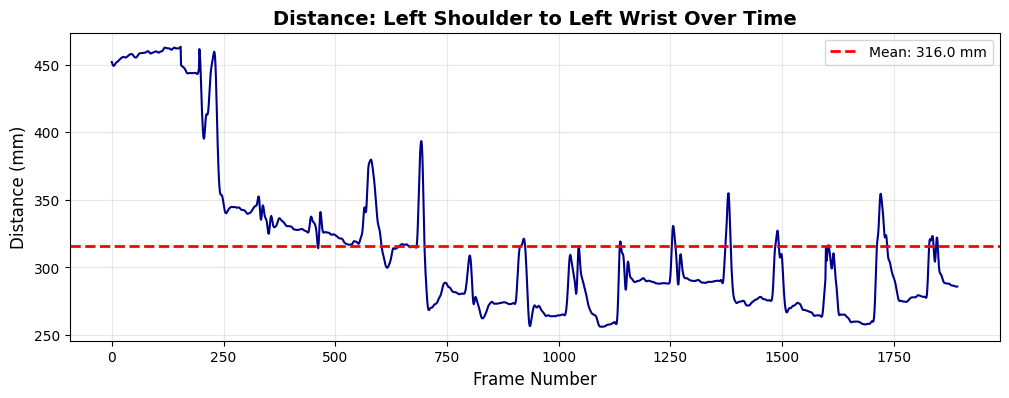


✓ Distance plot saved to: /Users/robertseymour/scripts/space_palm_game/recordings/sub-RS_task-space_validation_date-2026-02-18-15-40-08/block_01_left/visualizations/shoulder_wrist_distance.png
  Mean distance: 315.97 mm
  Std deviation: 57.76 mm


In [11]:
# Example: Calculate distance between two keypoints over time
from scipy.spatial.distance import euclidean

# Calculate distance from left shoulder to left wrist over all frames
left_shoulder_idx = 11
left_wrist_idx = 15

distances = []
for frame in range(points_3d.shape[0]):
    shoulder = points_3d[frame, left_shoulder_idx, :]
    wrist = points_3d[frame, left_wrist_idx, :]
    
    # Only calculate if both points are valid (not NaN)
    if not np.any(np.isnan(shoulder)) and not np.any(np.isnan(wrist)):
        dist = euclidean(shoulder, wrist)
        distances.append(dist)
    else:
        distances.append(np.nan)

distances = np.array(distances)

# Plot the distance over time
plt.figure(figsize=(12, 4))
plt.plot(distances, linewidth=1.5, color='darkblue')
plt.xlabel('Frame Number', fontsize=12)
plt.ylabel('Distance (mm)', fontsize=12)
plt.title('Distance: Left Shoulder to Left Wrist Over Time', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

# Add statistics
valid_distances = distances[~np.isnan(distances)]
plt.axhline(np.mean(valid_distances), color='red', linestyle='--', 
            label=f'Mean: {np.mean(valid_distances):.1f} mm', linewidth=2)
plt.legend()

distance_plot_path = Path(VISUALIZATION_DIR) / "shoulder_wrist_distance.png"
plt.savefig(distance_plot_path, dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✓ Distance plot saved to: {distance_plot_path}")
print(f"  Mean distance: {np.mean(valid_distances):.2f} mm")
print(f"  Std deviation: {np.std(valid_distances):.2f} mm")


## Summary of Outputs

In [12]:
print("\n" + "="*70)
print("OUTPUT FILES CREATED")
print("="*70)

print(f"\n3D Pose Data:")
print(f"  {Path(OUTPUT_3D_DIR) / 'pose_3d.npy'}")
print(f"  {Path(OUTPUT_3D_DIR) / 'pose_3d.json'}")

print(f"\nQuality Metrics:")
print(f"  {Path(OUTPUT_3D_DIR) / 'projection_metrics.txt'}")

print(f"\nVisualizations:")
print(f"  {Path(VISUALIZATION_DIR) / 'reprojection_errors.png'}")
print(f"  {Path(VISUALIZATION_DIR) / '3d_trajectories.png'}")
print(f"  {Path(VISUALIZATION_DIR) / 'shoulder_wrist_distance.png'}")



OUTPUT FILES CREATED

3D Pose Data:
  /Users/robertseymour/scripts/space_palm_game/recordings/sub-RS_task-space_validation_date-2026-02-18-15-40-08/block_01_left/data_3d/pose_3d.npy
  /Users/robertseymour/scripts/space_palm_game/recordings/sub-RS_task-space_validation_date-2026-02-18-15-40-08/block_01_left/data_3d/pose_3d.json

Quality Metrics:
  /Users/robertseymour/scripts/space_palm_game/recordings/sub-RS_task-space_validation_date-2026-02-18-15-40-08/block_01_left/data_3d/projection_metrics.txt

Visualizations:
  /Users/robertseymour/scripts/space_palm_game/recordings/sub-RS_task-space_validation_date-2026-02-18-15-40-08/block_01_left/visualizations/reprojection_errors.png
  /Users/robertseymour/scripts/space_palm_game/recordings/sub-RS_task-space_validation_date-2026-02-18-15-40-08/block_01_left/visualizations/3d_trajectories.png
  /Users/robertseymour/scripts/space_palm_game/recordings/sub-RS_task-space_validation_date-2026-02-18-15-40-08/block_01_left/visualizations/shoulder_wr

## Analyse and Post-Process the 3D pose data

In [13]:
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.patches as patches

from pose_analysis import (
    detect_person_orientation, 
    plot_reprojection_errors,
    align_pose_to_standard_frame,
    plot_aligned_skeleton,
    animate_3d_pose,
    animate_3d_pose_multiangle,
    interactive_pose_viewer,
    interpolate_nans
)

%matplotlib inline

In [14]:
# --- Derived paths ---
OUTPUT_DIR    = SESSION_DIR
POSE_3D_FILE  = SESSION_DIR / "data_3d" / "pose_3d.npy"

# --- Load data ---
assert POSE_3D_FILE.exists(), f"Missing file: {POSE_3D_FILE}"

points_3d = np.load(POSE_3D_FILE)
print(f"✓ Loaded 3D data: {points_3d.shape}")

✓ Loaded 3D data: (1893, 33, 3)


## Detect the person's orientation

Experimental

In [15]:
# Detect orientation (uses median across frames for robustness)
orientation = detect_person_orientation(points_3d)

print(f"\n✓ Detected orientation:")



DETECTING PERSON ORIENTATION

✓ UP direction detected: [0.280, -0.948, 0.151]
  Dominant axis: Y
✓ FORWARD direction detected: [-0.655, -0.304, -0.692]
✓ RIGHT direction detected: [-0.702, -0.094, 0.706]
✓ Ground plane detected at: 0.00 mm along up-axis

✓ Orientation detection complete!

✓ Detected orientation:


In [16]:
# 2. Align to anatomical frame
points_3d_aligned, R, orient = align_pose_to_standard_frame(points_3d)


DETECTING PERSON ORIENTATION

✓ UP direction detected: [0.280, -0.948, 0.151]
  Dominant axis: Y
✓ FORWARD direction detected: [-0.655, -0.304, -0.692]
✓ RIGHT direction detected: [-0.702, -0.094, 0.706]
✓ Ground plane detected at: 0.00 mm along up-axis

✓ Orientation detection complete!
Alignment check  UP->[-0.  0.  1.]  FWD->[0. 1. 0.]  RIGHT->[ 1.  0. -0.]


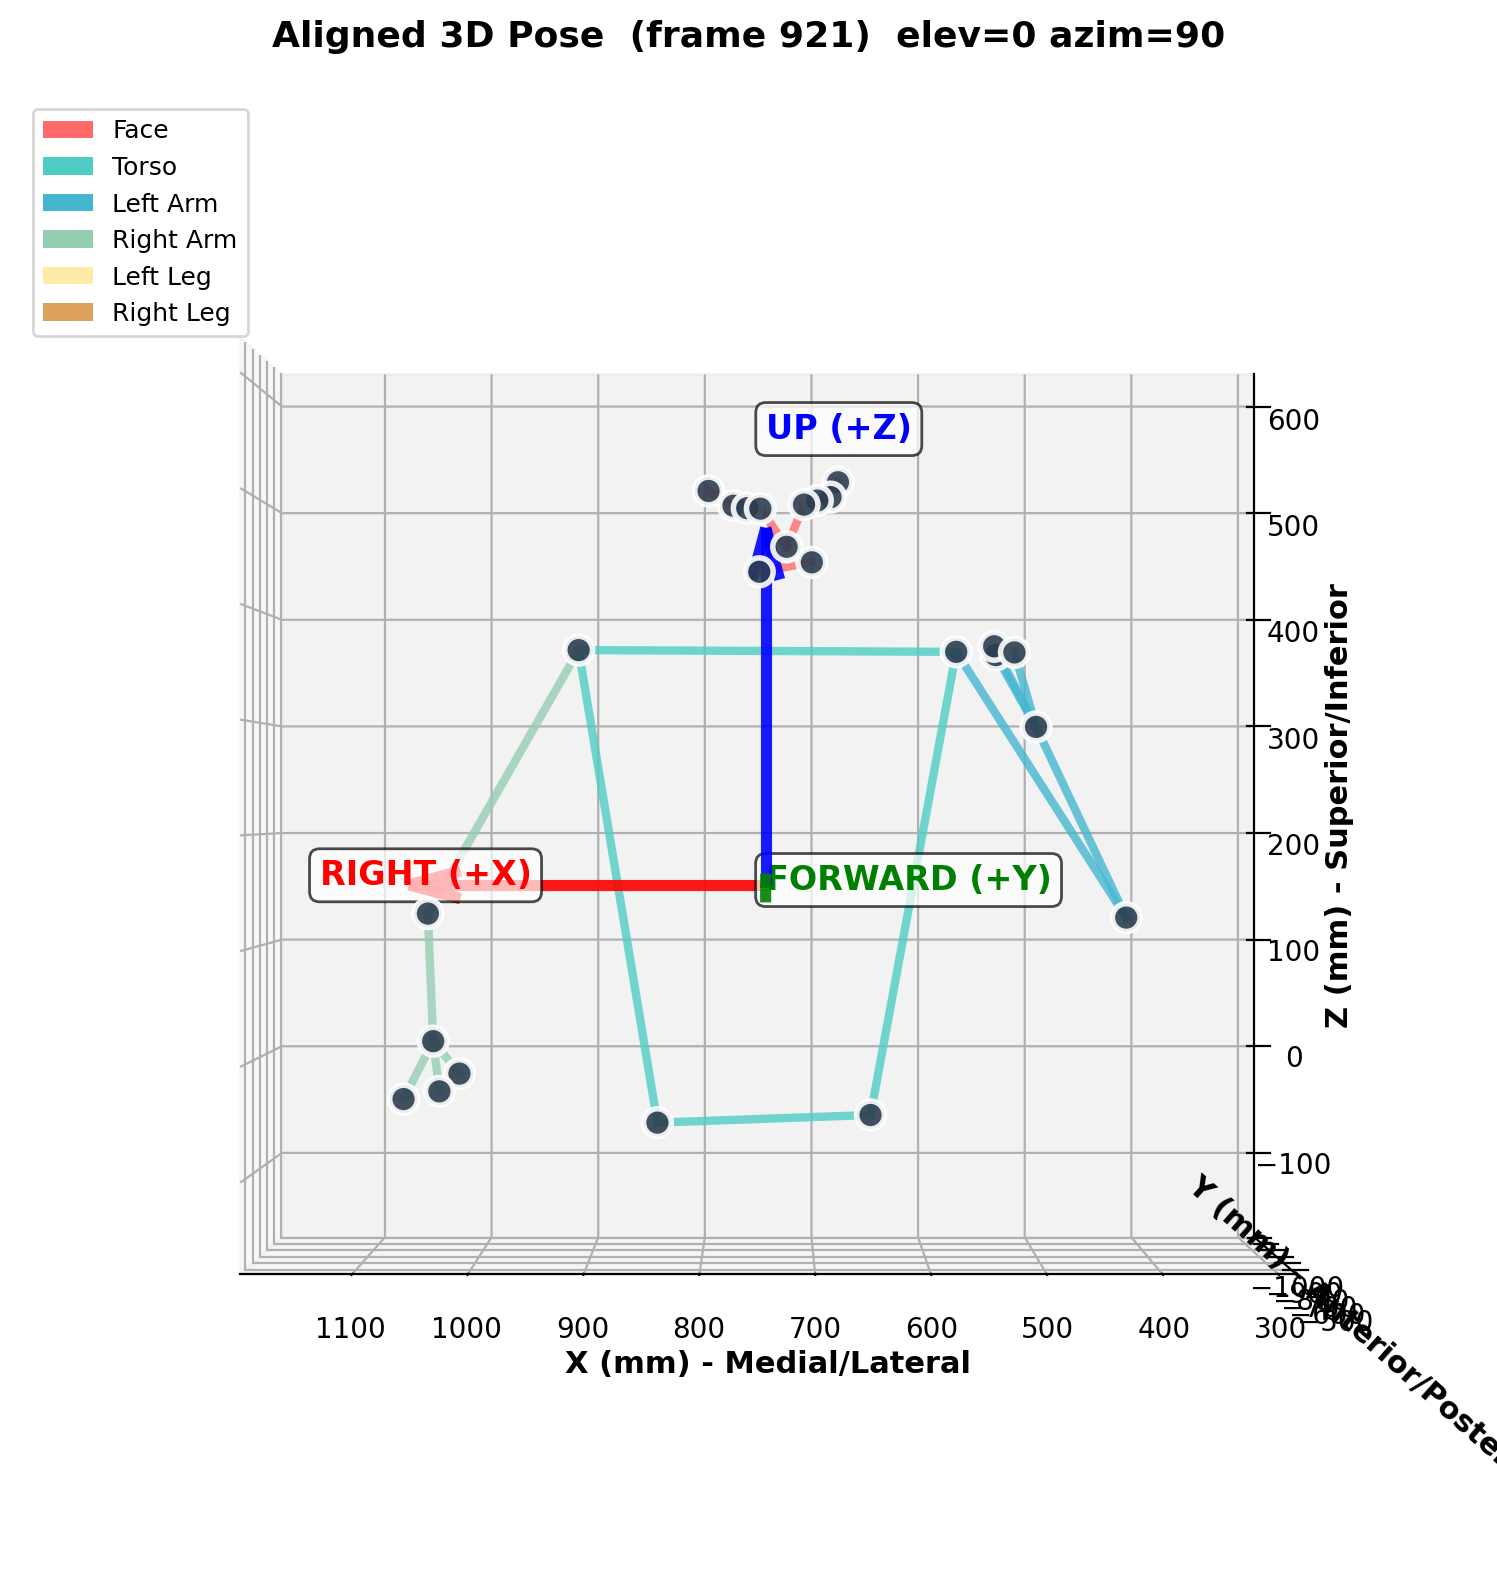

In [20]:
# 3. Static skeleton plot (no Qt needed)
%matplotlib qt
plot_aligned_skeleton(points_3d_aligned, elev=0, azim=90)

In [18]:
%matplotlib qt
interactive_pose_viewer(points_3d_aligned, fps=30,keypoint_size=70,line_width=4)

## Interpolate NaNs

### What PCHIP does (for mocap)

PCHIP (Piecewise Cubic Hermite Interpolating Polynomial) fills short missing
(NaN) segments in motion-capture data with a smooth, shape-preserving curve.
Each keypoint × coordinate (x, y, z) is treated as an independent 1-D signal.
The interpolated curve:

- Passes **exactly through** the surrounding valid samples  
- Is **C¹-continuous** (smooth position and velocity)  
- **Does not overshoot** between points (unlike cubic splines)

For mocap data, this typically produces natural-looking gap fills that preserve
local motion trends without introducing ringing or unrealistic excursions.


### Options you can tweak in `interpolate_nans(...)`

- **`method`**  
  Interpolation strategy:
  - `"pchip"` – Smooth, shape-preserving, no overshoot. Best default for mocap.
  - `"linear"` – Straight-line interpolation. Fast and safe, but creates visible
    kinks at gap boundaries.
  - `"savgol"` – Linear interpolation followed by Savitzky–Golay smoothing.
    Useful when surrounding data are noisy.

- **`max_gap_seconds`**  
  Maximum duration (in seconds) of a bounded NaN gap to fill.  
  Longer gaps are left as NaN.

- **`fps`**  
  Frame rate of the data. Used to convert `max_gap_seconds` into a frame count.

- **`savgol_window`** *(only for `method="savgol"`)*  
  Window length of the Savitzky–Golay filter (must be an odd integer).  
  Larger values give smoother results but may blur fast motion.

- **`savgol_polyorder`** *(only for `method="savgol"`)*  
  Polynomial order for the Savitzky–Golay filter.  
  Higher orders can follow curvature better but may fit noise.

- **`verbose`**  
  If `True`, prints a summary report of how many gaps and values were filled or
  skipped.


In [22]:
# PCHIP — best default, smooth & no overshoot
points_3d_filled, report = interpolate_nans(points_3d_aligned, method="pchip", max_gap_seconds=1.0, fps=30)

interactive_pose_viewer(points_3d_filled, fps=30,keypoint_size=70,line_width=4)


  INTERPOLATION REPORT  —  method: PCHIP
  max gap: 1.0s (30 frames @ 30 fps)
  Data shape        : (1842, 33, 3)
  Total values      :    182,358
  NaN before        :     44,259  ( 24.3%)
  Interpolated      :         51  (  0.0%)
  NaN after         :     44,208  ( 24.2%)
--------------------------------------------------------------
  Gaps found        :     30
    Filled          :      6
    Skipped (long)  :      0  (> 1.0s)
    Skipped (edge)  :     24  (leading/trailing/all-NaN)


## Animate the data and save to a real time video

In [23]:
# From the front
animate_3d_pose(
    points_3d_filled,
    show_floor=False,
    view_mode = 'rotating',
    rotation_speed=0,
    rotation_axis='z',
    output_path = OUTPUT_DIR / "animations" / "pose_front.mp4",
    elevation=0,
    azimuth_start=90,
    keypoint_size=70,
    line_width=4,
    show_axes=True,
    fps=30,
    quality='high'
)



CREATING 3D POSE ANIMATION

Settings:
  Frames: 1842/1842  FPS: 30  Duration: 61.40s
  View: rotating  Quality: high (DPI: 150)
  Rotation axis: Z  Speed: 0 deg/frame
  Output: /Users/robertseymour/scripts/space_palm_game/recordings/2026-02-17_16-05-54_validation/block_01_left/animations/pose_front.mp4

Generating animation frames...
Saving video to /Users/robertseymour/scripts/space_palm_game/recordings/2026-02-17_16-05-54_validation/block_01_left/animations/pose_front.mp4...


Rendering:   0%|          | 0/1842 [00:00<?, ?it/s]2026-02-17 17:19:44,445 - INFO - Animation.save using <class 'matplotlib.animation.FFMpegWriter'>
2026-02-17 17:19:44,446 - INFO - MovieWriter._run: running command: ffmpeg -f rawvideo -vcodec rawvideo -s 1800x1197 -pix_fmt rgba -framerate 30 -loglevel error -i pipe: -vcodec libx264 -b 5000k -y /Users/robertseymour/scripts/space_palm_game/recordings/2026-02-17_16-05-54_validation/block_01_left/animations/pose_front.mp4
Rendering: 100%|██████████| 1842/1842 [01:10<00:00, 26.14it/s]


✓ Animation saved! /Users/robertseymour/scripts/space_palm_game/recordings/2026-02-17_16-05-54_validation/block_01_left/animations/pose_front.mp4 (13.33 MB, 61.40s)


'/Users/robertseymour/scripts/space_palm_game/recordings/2026-02-17_16-05-54_validation/block_01_left/animations/pose_front.mp4'

## Combine with the original videos

In [20]:
from pathlib import Path
import cv2
import numpy as np

def open_or_raise(path: Path) -> cv2.VideoCapture:
    cap = cv2.VideoCapture(str(path))
    if not cap.isOpened():
        raise RuntimeError(f"Could not open video: {path}")
    return cap

def get_video_info(cap: cv2.VideoCapture):
    fps = cap.get(cv2.CAP_PROP_FPS)
    n = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    return fps, n, w, h

def fit_with_letterbox(frame, target_w, target_h):
    """Resize preserving aspect ratio; pad with black to exactly (target_w, target_h)."""
    if frame is None:
        return np.zeros((target_h, target_w, 3), dtype=np.uint8)

    h, w = frame.shape[:2]
    if w == 0 or h == 0:
        return np.zeros((target_h, target_w, 3), dtype=np.uint8)

    scale = min(target_w / w, target_h / h)
    new_w = max(1, int(w * scale))
    new_h = max(1, int(h * scale))

    resized = cv2.resize(frame, (new_w, new_h), interpolation=cv2.INTER_AREA)
    canvas = np.zeros((target_h, target_w, 3), dtype=np.uint8)

    x0 = (target_w - new_w) // 2
    y0 = (target_h - new_h) // 2
    canvas[y0:y0+new_h, x0:x0+new_w] = resized
    return canvas

def combine_cameras_and_multiplot(
    OUTPUT_DIR,
    synced_folder_name="synchronized_videos",
    multiplot_rel="animations/multiplot.mp4",
    out_name="animations/video_pose.mp4"
):
    """
    Combine synchronized camera videos with multi-angle 3D pose visualization.
    
    Layout:
    ┌─────────────┬─────────────┐
    │   Camera 0  │             │
    ├─────────────┤   Multiplot │
    │   Camera 1  │   (2x2 3D)  │
    ├─────────────┤             │
    │   Camera 2  │             │
    └─────────────┴─────────────┘
    
    Left side: 3 synchronized camera videos stacked vertically (2x1 layout)
    Right side: Multi-angle 3D pose animation (multiplot.mp4)
    
    Args:
        OUTPUT_DIR: Base output directory
        synced_folder_name: Folder containing synchronized videos
        multiplot_rel: Path to multiplot.mp4 relative to OUTPUT_DIR
        out_name: Output filename relative to OUTPUT_DIR
        
    Returns:
        str: Path to saved combined video
    """
    
    OUTPUT_DIR = Path(OUTPUT_DIR)
    synced_dir = OUTPUT_DIR / synced_folder_name
    multiplot_path = OUTPUT_DIR / multiplot_rel
    out_path = OUTPUT_DIR / out_name
    
    # Validate inputs
    if not multiplot_path.exists():
        raise FileNotFoundError(f"Missing multiplot video: {multiplot_path}")
    if not synced_dir.exists():
        raise FileNotFoundError(f"Missing synchronized videos folder: {synced_dir}")
    
    # Get exactly 3 camera videos
    camera_paths = sorted(synced_dir.glob("camera_*_synchronized.mp4"))[:3]
    if len(camera_paths) < 3:
        raise FileNotFoundError(f"Need at least 3 camera videos in {synced_dir}, found {len(camera_paths)}")
    
    print("="*70)
    print("COMBINING CAMERA VIDEOS + MULTIPLOT 3D VISUALIZATION")
    print("="*70)
    
    # Open all captures
    cap_multiplot = open_or_raise(multiplot_path)
    caps_cameras = [open_or_raise(p) for p in camera_paths]
    
    # Get video info
    fps_multi, n_multi, multi_w, multi_h = get_video_info(cap_multiplot)
    camera_infos = [get_video_info(c) for c in caps_cameras]
    
    # Use multiplot FPS as reference
    out_fps = fps_multi if fps_multi and fps_multi > 0 else 30.0
    
    print(f"\nVideo information:")
    print(f"  Multiplot: {multi_w}x{multi_h} @ {fps_multi:.2f} fps, {n_multi} frames")
    for i, (fps, n, w, h) in enumerate(camera_infos):
        print(f"  Camera {i}: {w}x{h} @ {fps:.2f} fps, {n} frames")
    
    # Sync: trim to minimum frame count across all videos
    min_frames = min(
        n_multi,
        *[info[1] for info in camera_infos]
    )
    
    if min_frames <= 0:
        raise RuntimeError("Could not determine valid frame counts (min_frames <= 0).")
    
    print(f"\nOutput settings:")
    print(f"  Synchronized frames: {min_frames}")
    print(f"  Duration: {min_frames/out_fps:.2f} seconds")
    print(f"  FPS: {out_fps:.2f}")
    
    # ========================================================================
    # Layout calculations
    # ========================================================================
    
    # Left side: Stack 3 cameras vertically
    # Make left side same height as multiplot
    left_w = multi_w  # Same width as multiplot for 50/50 split
    left_h = multi_h
    
    # Each camera cell height
    camera_cell_h = left_h // 3
    
    # Right side: Multiplot (keep original size)
    right_w = multi_w
    right_h = multi_h
    
    # Output dimensions
    out_w = left_w + right_w
    out_h = max(left_h, right_h)
    
    print(f"  Layout:")
    print(f"    Left (cameras): {left_w}x{left_h} (3 cameras stacked)")
    print(f"    Right (multiplot): {right_w}x{right_h}")
    print(f"    Output size: {out_w}x{out_h}")
    
    # ========================================================================
    # Create output video
    # ========================================================================
    
    out_path.parent.mkdir(parents=True, exist_ok=True)
    
    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    writer = cv2.VideoWriter(str(out_path), fourcc, out_fps, (out_w, out_h))
    if not writer.isOpened():
        raise RuntimeError(f"Could not open writer: {out_path}")
    
    print(f"\nWriting combined video...")
    
    # Process each frame
    for frame_idx in range(min_frames):
        if frame_idx % 100 == 0:
            print(f"  Processing frame {frame_idx}/{min_frames}...")
        
        # Read multiplot frame (right side)
        ok_multi, f_multi = cap_multiplot.read()
        if not ok_multi or f_multi is None:
            f_multi = np.zeros((right_h, right_w, 3), dtype=np.uint8)
        else:
            # Ensure exact size
            if f_multi.shape[:2] != (right_h, right_w):
                f_multi = cv2.resize(f_multi, (right_w, right_h), interpolation=cv2.INTER_AREA)
        
        # Read camera frames (left side)
        camera_frames = []
        for cap in caps_cameras:
            ok, f = cap.read()
            if not ok or f is None:
                f = None
            # Fit into camera cell with letterbox
            camera_frames.append(fit_crop_fill(f, left_w, camera_cell_h))
        
        # Stack camera frames vertically
        left_side = np.vstack(camera_frames)
        
        # Ensure left side is exact height
        if left_side.shape[0] != left_h:
            left_side = cv2.resize(left_side, (left_w, left_h), interpolation=cv2.INTER_AREA)
        
        # Combine left (cameras) and right (multiplot) horizontally
        frame_out = np.hstack([left_side, f_multi])
        
        writer.write(frame_out)
    
    # Cleanup
    writer.release()
    cap_multiplot.release()
    for c in caps_cameras:
        c.release()
    
    print(f"\n✅ Combined video saved successfully!")
    print(f"  Output: {out_path}")
    print(f"  Size: {out_w}x{out_h}")
    print(f"  Frames: {min_frames}")
    print(f"  Duration: {min_frames/out_fps:.2f}s")
    
    return str(out_path)



In [21]:

result = combine_cameras_and_multiplot(
    OUTPUT_DIR=OUTPUT_DIR,
    synced_folder_name="synchronized_videos",
    multiplot_rel="animations/multiplot.mp4",
    out_name="animations/video_pose.mp4"
)



COMBINING CAMERA VIDEOS + MULTIPLOT 3D VISUALIZATION


[mov,mp4,m4a,3gp,3g2,mj2 @ 0x144823f50] moov atom not found
OpenCV: Couldn't read video stream from file "/Users/robertseymour/Documents/recordings/2026-02-11_15-04-22/animations/multiplot.mp4"


RuntimeError: Could not open video: /Users/robertseymour/Documents/recordings/2026-02-11_15-04-22/animations/multiplot.mp4

## Combine this video with the labelled videos!

COMBINING 4 SYNCHRONIZED VIDEOS (2x2 GRID)

Video information:
  Video 0: 1024x576 @ 30.00 fps, 2700 frames   (camera_0_synchronized_labeled.mp4)
  Video 1: 1024x576 @ 30.00 fps, 2700 frames   (camera_1_synchronized_labeled.mp4)
  Video 2: 1024x576 @ 30.00 fps, 2700 frames   (camera_2_synchronized_labeled.mp4)
  Video 3: 1024x576 @ 30.00 fps, 2700 frames   (camera_3_synchronized_labeled.mp4)

Output settings:
  Synchronized frames: 2700
  Duration: 90.00 seconds
  FPS: 30.00

Layout (pre-final):
  Row0 target width per cell: 1024, row0 enforced height: 576, native row0: 2048x576
  Row1 target width per cell: 1024, row1 enforced height: 576, native row1: 2048x576
  Common row height (no padding): 576

Final output size (no padding): 2048x1152 (each row ~ 2048x576)

Writing combined video...
  Processing frame 0/2700...
  Processing frame 100/2700...
  Processing frame 200/2700...
  Processing frame 300/2700...
  Processing frame 400/2700...
  Processing frame 500/2700...
  Processing fr

In [ ]:
from pathlib import Path
import math
import cv2
import numpy as np


def open_or_raise(path: Path) -> cv2.VideoCapture:
    cap = cv2.VideoCapture(str(path))
    if not cap.isOpened():
        raise RuntimeError(f"Could not open video: {path}")
    return cap


def get_video_info(cap: cv2.VideoCapture):
    fps = cap.get(cv2.CAP_PROP_FPS)
    n = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    return fps, n, w, h


def resize_to_width(frame, target_w):
    """Resize to target_w preserving aspect ratio (no padding/cropping)."""
    if frame is None:
        return None
    h, w = frame.shape[:2]
    if w <= 0 or h <= 0:
        return None
    scale = target_w / w
    new_h = max(1, int(round(h * scale)))
    return cv2.resize(frame, (target_w, new_h), interpolation=cv2.INTER_AREA)


def compute_grid_dims(n: int) -> tuple[int, int]:
    """
    Return (n_cols, n_rows) for a grid that sensibly fits n videos.

    Strategy: favour landscape grids (cols >= rows).
    - 1  → 1x1
    - 2  → 2x1
    - 3  → 3x1  (side-by-side strip; swap to 2x2 with blank if you prefer)
    - 4  → 2x2
    - 5  → 3x2  (last row has 2 centred cells)
    - 6  → 3x2
    - 7  → 4x2
    - 8  → 4x2
    - 9  → 3x3
    - …  → ceil(sqrt(n)) cols, ceil(n/cols) rows
    """
    if n <= 0:
        raise ValueError("n must be >= 1")
    n_cols = math.ceil(math.sqrt(n))
    n_rows = math.ceil(n / n_cols)
    return n_cols, n_rows


def build_grid_frame(
    cam_frames: list,
    infos: list,
    n_cols: int,
    n_rows: int,
    grid_w: int,
    grid_h: int,
) -> np.ndarray:
    """
    Arrange cam_frames into an (grid_w x grid_h) mosaic.

    Each cell is sized (cell_w x cell_h).  Frames are fitted inside their cell
    with aspect-ratio preservation (letterbox / pillarbox with black fill only
    at the cell level – the overall grid has no extra padding).
    The last row is centred if it is not full.
    """
    n = len(cam_frames)
    cell_w = grid_w // n_cols
    cell_h = grid_h // n_rows

    canvas = np.zeros((grid_h, grid_w, 3), dtype=np.uint8)

    for idx in range(n_rows * n_cols):
        row = idx // n_cols
        col = idx % n_cols

        # Centre the last (potentially partial) row
        last_row_count = n - (n_rows - 1) * n_cols
        if row == n_rows - 1 and last_row_count < n_cols:
            # shift right so the occupied cells are centred
            col_offset = (n_cols - last_row_count) * cell_w // 2
        else:
            col_offset = 0

        x0 = col * cell_w + col_offset
        y0 = row * cell_h

        if idx >= n or cam_frames[idx] is None:
            # Empty cell – leave black
            continue

        frame = cam_frames[idx]
        fh, fw = frame.shape[:2]

        # Fit frame into cell while preserving aspect ratio
        scale = min(cell_w / fw, cell_h / fh)
        new_fw = max(1, int(round(fw * scale)))
        new_fh = max(1, int(round(fh * scale)))
        resized = cv2.resize(frame, (new_fw, new_fh), interpolation=cv2.INTER_AREA)

        # Centre within cell
        pad_x = (cell_w - new_fw) // 2
        pad_y = (cell_h - new_fh) // 2

        y1 = y0 + pad_y
        x1 = x0 + pad_x
        # Guard against off-canvas writes
        y2 = min(y1 + new_fh, grid_h)
        x2 = min(x1 + new_fw, grid_w)
        canvas[y1:y2, x1:x2] = resized[: y2 - y1, : x2 - x1]

    return canvas


def combine_cameras_and_front_view(
    OUTPUT_DIR,
    synced_folder_name="synchronized_videos",
    front_view_rel="animations/pose_front.mp4",
    out_name="animations/video_pose.mp4",
    camera_glob="camera_*_synchronized_labeled.mp4",
    grid_target_h: int = 1080,
    front_view_width_ratio: float = 0.35,
):
    """
    Combine any number of synchronized camera videos (auto grid) with a front
    view 3D pose visualization.

    LAYOUT:
    - Left:  N camera videos arranged in an auto-sized grid that fills the
             left panel without borders.  The grid dimensions are chosen to be
             roughly square (cols >= rows).  If the last row is not full, those
             cells are horizontally centred.
    - Right: front-view video resized to match the full left-grid height
             (aspect-ratio preserved).
    - Output: [camera grid | front view]

    Args:
        OUTPUT_DIR:            Base output directory.
        synced_folder_name:    Folder (relative to OUTPUT_DIR) containing the
                               synchronized camera videos.
        front_view_rel:        Path to pose_front.mp4 relative to OUTPUT_DIR.
        out_name:              Output filename relative to OUTPUT_DIR.
        camera_glob:           Glob pattern to find labelled synchronized
                               camera videos inside synced_folder_name.
        grid_target_h:         Target height (px) for the camera grid.  Width
                               is derived from the source videos' aspect ratios.
        front_view_width_ratio: Approximate fraction of total output width
                               reserved for the front view (used only when the
                               front view's natural size is very different from
                               the grid; the grid height is always the master).

    Returns:
        str: Path to saved combined video.
    """
    OUTPUT_DIR = Path(OUTPUT_DIR)
    synced_dir = OUTPUT_DIR / synced_folder_name
    front_view_path = OUTPUT_DIR / front_view_rel
    out_path = OUTPUT_DIR / out_name

    # ------------------------------------------------------------------
    # Validate inputs
    # ------------------------------------------------------------------
    if not front_view_path.exists():
        raise FileNotFoundError(f"Missing front view video: {front_view_path}")
    if not synced_dir.exists():
        raise FileNotFoundError(
            f"Missing synchronized videos folder: {synced_dir}"
        )

    camera_paths = sorted(synced_dir.glob(camera_glob))
    n_cams = len(camera_paths)
    if n_cams == 0:
        raise FileNotFoundError(
            f"No camera videos found in {synced_dir} matching '{camera_glob}'"
        )

    print("=" * 70)
    print(f"COMBINING {n_cams}-CAMERA GRID + FRONT VIEW 3D VISUALIZATION")
    print("=" * 70)

    # ------------------------------------------------------------------
    # Open captures & collect info
    # ------------------------------------------------------------------
    cap_front = open_or_raise(front_view_path)
    caps = [open_or_raise(p) for p in camera_paths]

    fps_front, n_front, front_w, front_h = get_video_info(cap_front)
    infos = [get_video_info(c) for c in caps]

    out_fps = fps_front if fps_front and fps_front > 0 else 30.0

    print("\nVideo information:")
    print(
        f"  Front view : {front_w}x{front_h} @ {fps_front:.2f} fps,"
        f" {n_front} frames"
    )
    for i, (fps, n, w, h) in enumerate(infos):
        print(
            f"  Camera {i:>2}  : {w}x{h} @ {fps:.2f} fps, {n} frames"
            f"   ({camera_paths[i].name})"
        )

    # ------------------------------------------------------------------
    # Sync: use the shortest video across all inputs
    # ------------------------------------------------------------------
    min_frames = min(n_front, *[info[1] for info in infos])
    if min_frames <= 0:
        raise RuntimeError(
            "Could not determine valid frame counts (min_frames <= 0)."
        )

    print("\nOutput settings:")
    print(f"  Synchronized frames : {min_frames}")
    print(f"  Duration            : {min_frames / out_fps:.2f} seconds")
    print(f"  FPS                 : {out_fps:.2f}")

    # ------------------------------------------------------------------
    # Layout
    # ------------------------------------------------------------------
    n_cols, n_rows = compute_grid_dims(n_cams)
    print(f"\nGrid layout: {n_cams} cameras → {n_cols} cols × {n_rows} rows")

    # Derive a sensible cell size from the median source resolution
    src_ws = [info[2] for info in infos]
    src_hs = [info[3] for info in infos]
    median_w = sorted(src_ws)[len(src_ws) // 2]
    median_h = sorted(src_hs)[len(src_hs) // 2]

    # Cell size: fit median source into (grid_target_h / n_rows) tall cell
    cell_h = max(1, grid_target_h // n_rows)
    cell_w = max(1, int(round(median_w * (cell_h / median_h))))

    grid_w = cell_w * n_cols
    grid_h = cell_h * n_rows  # may differ slightly from grid_target_h

    # Front view: height matches grid, width preserves aspect ratio
    right_h = grid_h
    right_w = max(1, int(round(front_w * (right_h / front_h))))

    out_w = grid_w + right_w
    out_h = grid_h

    print("\nLayout:")
    print(f"  Cell size       : {cell_w}x{cell_h}")
    print(f"  Grid size       : {grid_w}x{grid_h}")
    print(f"  Front view size : {right_w}x{right_h}")
    print(f"  Output size     : {out_w}x{out_h}")

    # ------------------------------------------------------------------
    # Writer
    # ------------------------------------------------------------------
    out_path.parent.mkdir(parents=True, exist_ok=True)
    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    writer = cv2.VideoWriter(str(out_path), fourcc, out_fps, (out_w, out_h))
    if not writer.isOpened():
        raise RuntimeError(f"Could not open writer: {out_path}")

    print("\nWriting combined video...")

    # ------------------------------------------------------------------
    # Frame loop
    # ------------------------------------------------------------------
    for frame_idx in range(min_frames):
        if frame_idx % 100 == 0:
            print(f"  Processing frame {frame_idx}/{min_frames}...")

        # Read camera frames
        cam_frames = []
        for cap in caps:
            ok, f = cap.read()
            cam_frames.append(f if ok and f is not None else None)

        # Build camera grid
        grid_left = build_grid_frame(
            cam_frames, infos, n_cols, n_rows, grid_w, grid_h
        )

        # Front view frame
        ok_front, f_front = cap_front.read()
        if not ok_front or f_front is None:
            f_front = np.zeros((right_h, right_w, 3), dtype=np.uint8)
        else:
            f_front = cv2.resize(
                f_front, (right_w, right_h), interpolation=cv2.INTER_AREA
            )

        frame_out = np.hstack([grid_left, f_front])
        writer.write(frame_out)

    # ------------------------------------------------------------------
    # Cleanup
    # ------------------------------------------------------------------
    writer.release()
    cap_front.release()
    for c in caps:
        c.release()

    print("\n✅ Combined video saved successfully!")
    print(f"  Output   : {out_path}")
    print(f"  Size     : {out_w}x{out_h}")
    print(f"  Frames   : {min_frames}")
    print(f"  Duration : {min_frames / out_fps:.2f}s")

    return str(out_path)


# Example call:
result = combine_cameras_and_front_view(
    OUTPUT_DIR=OUTPUT_DIR,
    synced_folder_name="mediapipe_output/labeled_videos",
    front_view_rel="animations/pose_front.mp4",
    out_name="animations/video_pose2.mp4",
)
print("Saved:", result)

COMBINING 3-CAMERA GRID + FRONT VIEW 3D VISUALIZATION

Video information:
  Front view : 1800x1197 @ 30.00 fps, 1842 frames
  Camera  0  : 1024x576 @ 30.00 fps, 1842 frames   (camera_0_synchronized_labeled.mp4)
  Camera  1  : 1024x576 @ 30.00 fps, 1842 frames   (camera_1_synchronized_labeled.mp4)
  Camera  2  : 1024x576 @ 30.00 fps, 1842 frames   (camera_2_synchronized_labeled.mp4)

Output settings:
  Synchronized frames : 1842
  Duration            : 61.40 seconds
  FPS                 : 30.00

Grid layout: 3 cameras → 2 cols × 2 rows

Layout:
  Cell size       : 960x540
  Grid size       : 1920x1080
  Front view size : 1624x1080
  Output size     : 3544x1080

Writing combined video...
  Processing frame 0/1842...
  Processing frame 100/1842...
  Processing frame 200/1842...
  Processing frame 300/1842...
  Processing frame 400/1842...
  Processing frame 500/1842...
  Processing frame 600/1842...
  Processing frame 700/1842...
  Processing frame 800/1842...
  Processing frame 900/1842

: 